# Live Coding


1. Setup

* “Vamos a comparar probabilidad teórica vs simulación. Si repetimos muchas veces, las frecuencias se acercan a la teoría.”

In [1]:
import numpy as np
import pandas as pd
from itertools import product

rng = np.random.default_rng(42)  # reproducible


2. Simulamos el lanzamiento de un dado y una moneda

In [2]:
# Una corrida
moneda = rng.choice(["C", "S"])      # C=cara, S=sello
dado = rng.integers(1, 7)            # 1..6
(moneda, dado)


(np.str_('C'), np.int64(5))

3. Representamos el espacio muestral combinado

* El espacio muestral son todos los pares (moneda, dado)

In [3]:
S = list(product(["C", "S"], range(1, 7)))
S, len(S)


([('C', 1),
  ('C', 2),
  ('C', 3),
  ('C', 4),
  ('C', 5),
  ('C', 6),
  ('S', 1),
  ('S', 2),
  ('S', 3),
  ('S', 4),
  ('S', 5),
  ('S', 6)],
 12)

["C","S"] son los posibles resultados de la moneda: Cara (C) o Sello (S).

range(1,7) genera los posibles resultados del dado: 1, 2, 3, 4, 5, 6 (ojo: el 7 no se incluye).

product(...) (de itertools) arma el producto cartesiano: todas las combinaciones posibles entre moneda y dado.

4. Calculamos probabilidades simples

Teórica

In [4]:
A = [(m, d) for (m, d) in S if d % 2 == 1]  # dado impar
A, len(A), len(S), len(A)/len(S)


([('C', 1), ('C', 3), ('C', 5), ('S', 1), ('S', 3), ('S', 5)], 6, 12, 0.5)

Simulada

In [5]:
N = 10000
monedas = rng.choice(["C", "S"], size=N)
dados = rng.integers(1, 7, size=N)

df = pd.DataFrame({"moneda": monedas, "dado": dados})
p_sim_impar = (df["dado"] % 2 == 1).mean()
p_sim_impar


np.float64(0.5025)

5. Regla del producto en eventos sucesivos

Define dos eventos:
* B: “¿Salió cara?”
* C: “¿Salió 6?”

P(B∩C)=P(B)⋅P(C)= (1/2) * (1/6)​= 1/12​

Teórica:

In [6]:
p_teo = (1/2) * (1/6)
p_teo


0.08333333333333333

Simulada:

In [7]:
p_sim = ((df["moneda"] == "C") & (df["dado"] == 6)).mean()
p_sim


np.float64(0.0787)

6. Usamos random/numpy para reproducir experimentos múltiples (y ver convergencia)

In [8]:
def sim_prob(N, seed=42):
    r = np.random.default_rng(seed)
    monedas = r.choice(["C", "S"], size=N)
    dados = r.integers(1, 7, size=N)
    return ((monedas == "C") & (dados == 6)).mean()

Ns = [10, 50, 100, 500, 1000, 10000]
tabla = pd.DataFrame({
    "N": Ns,
    "P_sim(C y 6)": [sim_prob(n) for n in Ns],
    "P_teo(C y 6)": [1/12]*len(Ns)
})
tabla


,N,P_sim(C y 6),P_teo(C y 6)
0,10,0.1000,0.083333
1,50,0.0400,0.083333
2,100,0.0400,0.083333
3,500,0.0880,0.083333
4,1000,0.0980,0.083333
5,10000,0.0787,0.083333


7. Árbol de probabilidades para organizar resultados

* Nivel 1: C (1/2), S (1/2)
* Nivel 2 desde cada rama: 1..6 (1/6 cada uno)

Cada hoja=1/12 x 1/2 = 1/12

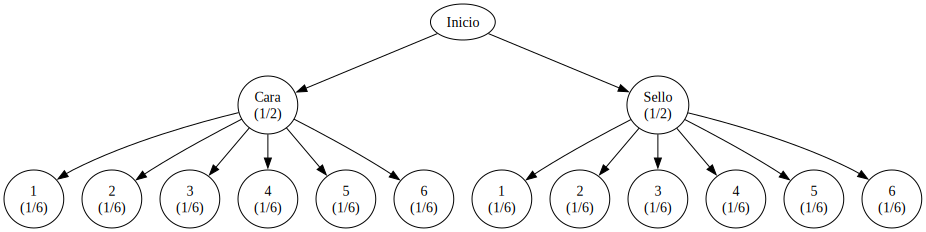

In [9]:
from graphviz import Digraph

dot = Digraph()
dot.node("I", "Inicio")

dot.node("C", "Cara\n(1/2)")
dot.node("S", "Sello\n(1/2)")
dot.edge("I", "C")
dot.edge("I", "S")

for i in range(1, 7):
    dot.node(f"C{i}", f"{i}\n(1/6)")
    dot.node(f"S{i}", f"{i}\n(1/6)")
    dot.edge("C", f"C{i}")
    dot.edge("S", f"S{i}")

dot


8.Cierre:

En los datos reales, la aleatoriedad no significa falta de sentido, sino variabilidad natural.
Nuestro objetivo como analistas no es eliminarla, sino comprenderla y modelarla para extraer información confiable.


En Data Science, los datos nunca son perfectamente determinísticos.
La presencia de aleatoriedad es inevitable, y reconocerla es clave para interpretar resultados, estimar incertidumbre y tomar decisiones informadas

# Ejercicio 1

## 1) Definimos eventos

**Evento real**

F: la transacción sí es fraude

¬F: la transacción no es fraude


**Evento del modelo (predicción):**

M: el modelo indica “Fraude”

¬M: el modelo indica “No Fraude”

Parámetros del ejercicio:

- \(P(F)=0.10\)
- \(P(¬F)=0.90\) = 1 - \(P(F)=0.10\)
- \(P(M | F)=0.90\)  (sensibilidad / recall) ¿Qué tan bien detecto los fraudes que existen?
- \(P(M | ¬F)=0.05\) (falso positivo)


*De todas las transacciones, solo un 10% son realmente fraude.*

En notación:
* P(F) = 0.10
* P(¬F) = 0.90

*Probabilidad de que el modelo lo detecte como fraude si lo es (90%)*

En notación:
* P(M | F) = 0.90

*Probabilidad de que el modelo detecte fraude en una transacción que no lo es (5%)*

En notación:
* P(M | ¬F) = 0.05

Esto es el falso positivo.

**Árbol de Probabilidad**


**Nivel 1**: Realidad
* Fraude (0.10)
* No Fraude (0.90)


**Nivel 2**: Decisión del modelo

Desde Fraude (0.10):
* Detecta fraude (0.90)
* No detecta (0.10)

Desde No Fraude (0.90):
* Detecta fraude (0.05)
* No detecta (0.95)

**Cargar parámetros en Python**

In [10]:
# Caminos del árbol (probabilidades conjuntas)
# -----------------------------
# Probabilidades base
# -----------------------------

p_F = 0.10          # Probabilidad de fraude real
p_notF = 0.90       # Probabilidad de no fraude

# -----------------------------
# Probabilidades condicionales
# -----------------------------

p_M_given_F = 0.90         # Sensibilidad (detecta fraude si es fraude)
p_notM_given_F = 0.10      # Falso negativo

p_M_given_notF = 0.05      # Falso positivo
p_notM_given_notF = 0.95   # Especificidad

# -----------------------------
# Caminos del árbol (probabilidades conjuntas)
# -----------------------------

# 1 Verdadero Positivo
p_VP = p_F * p_M_given_F

# 2 Falso Negativo
p_FN = p_F * p_notM_given_F

# 3 Falso Positivo
p_FP = p_notF * p_M_given_notF

# 4 Verdadero Negativo
p_VN = p_notF * p_notM_given_notF

# Mostrar resultados
p_VP, p_FN, p_FP, p_VN



(0.09000000000000001, 0.010000000000000002, 0.045000000000000005, 0.855)

Probabilidad total de que el modelo indique “Fraude” (P(M))

*Nota: La probabilidad total de que el modelo indique “Fraude” no es otra cosa que sumar los caminos que terminan en esa decisión.*

In [11]:
# Probabilidad total de que el modelo indique fraude (Ley de probabilidad total)
p_M = p_VP + p_FP
p_M


0.135

Calcule la probabilidad de que, dado que el modelo indicó fraude, realmente lo sea (regla de Bayes)

Bayes: P(F | M)

In [12]:
# # 1 Verdadero Positivo
# p_VP = p_F * p_M_given_F

# Probabilidad total de que el modelo indique fraude (Ley de probabilidad total)
# p_M = p_VP + p_FP

# Bayes: probabilidad de fraude real dado que el modelo marcó fraude
p_F_given_M = p_VP / p_M
p_F_given_M


0.6666666666666667

Resumen

In [13]:
print("Resultados:")
print(f"P(M) = {p_M:.3f}  → el modelo marca fraude en {p_M*100:.1f}% de las transacciones")
print(f"P(F|M) = {p_F_given_M:.3f} → si el modelo marca fraude, {p_F_given_M*100:.1f}% es fraude real")


Resultados:
P(M) = 0.135  → el modelo marca fraude en 13.5% de las transacciones
P(F|M) = 0.667 → si el modelo marca fraude, 66.7% es fraude real


## Interpretación

- El modelo marca fraude en **13.5%** de las transacciones.
- Pero, cuando marca fraude, solo **≈66.7%** de esas alertas son realmente fraude.

**Idea clave:** aunque el modelo tenga buen recall (90%) y pocos falsos positivos (5%),  
el fraude es poco frecuente (10%), y eso afecta mucho la confiabilidad de una alerta.


### **árbol de probabilidades**

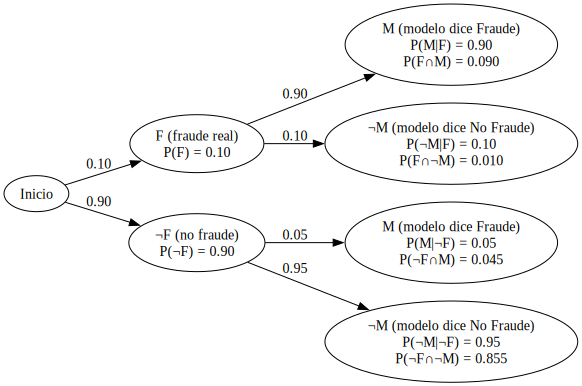

In [14]:
from graphviz import Digraph

# Parámetros (ajusta si quieres)
p_F = 0.10
p_notF = 1 - p_F

p_M_given_F = 0.90
p_notM_given_F = 1 - p_M_given_F

p_M_given_notF = 0.05
p_notM_given_notF = 1 - p_M_given_notF

# Probabilidades conjuntas (para mostrar en hojas)
p_F_M = p_F * p_M_given_F
p_F_notM = p_F * p_notM_given_F
p_notF_M = p_notF * p_M_given_notF
p_notF_notM = p_notF * p_notM_given_notF

dot = Digraph("ArbolProb", format="png")
dot.attr(rankdir="LR", fontsize="12")

# Nodos
dot.node("S", "Inicio")
dot.node("F",  f"F (fraude real)\nP(F) = {p_F:.2f}")
dot.node("nF", f"¬F (no fraude)\nP(¬F) = {p_notF:.2f}")

dot.node("FM",  f"M (modelo dice Fraude)\nP(M|F) = {p_M_given_F:.2f}\nP(F∩M) = {p_F_M:.3f}")
dot.node("FnM", f"¬M (modelo dice No Fraude)\nP(¬M|F) = {p_notM_given_F:.2f}\nP(F∩¬M) = {p_F_notM:.3f}")

dot.node("nFM",  f"M (modelo dice Fraude)\nP(M|¬F) = {p_M_given_notF:.2f}\nP(¬F∩M) = {p_notF_M:.3f}")
dot.node("nFnM", f"¬M (modelo dice No Fraude)\nP(¬M|¬F) = {p_notM_given_notF:.2f}\nP(¬F∩¬M) = {p_notF_notM:.3f}")

# Aristas
dot.edge("S", "F",  label=f"{p_F:.2f}")
dot.edge("S", "nF", label=f"{p_notF:.2f}")

dot.edge("F",  "FM",  label=f"{p_M_given_F:.2f}")
dot.edge("F",  "FnM", label=f"{p_notM_given_F:.2f}")

dot.edge("nF", "nFM",  label=f"{p_M_given_notF:.2f}")
dot.edge("nF", "nFnM", label=f"{p_notM_given_notF:.2f}")

dot


# **PARTE 2**

## Live Coding

Modelaremos un test diagnóstico con sensibilidad y tasa de falsos positivos, analizando cómo la prevalencia de la enfermedad influye en la probabilidad real de padecerla dado un resultado positivo.

0. Setup

In [15]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")  # opción controla el formato de visualización de números en pandas


1. Simularemos un test de diagnóstico con falso positivo/falso negativo

Simularemos 50,000 individuos evaluados con una prueba diagnóstica:

Parámetros:
* Prevalencia (10%): 10% de la población tiene la condición
* Sensibilidad (90%): La prueba detecta correctamente el 90% de los casos positivos
* Tasa de falsos positivos (5%): La prueba da positivo en el 5% de los sanos

### **árbol de probabilidades**

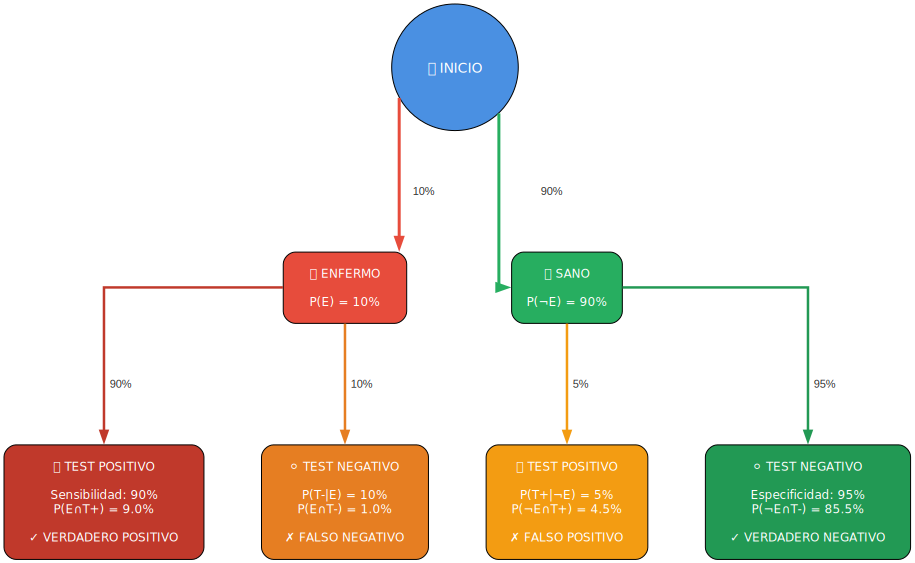

In [16]:
from graphviz import Digraph

# -----------------------------
# Parámetros del test (caso diagnóstico)
# -----------------------------
p_E = 0.10                 # Prevalencia: P(E) = prob. de enfermedad
p_notE = 1 - p_E

p_Tpos_given_E = 0.90      # Sensibilidad: P(T+ | E)
p_Tneg_given_E = 1 - p_Tpos_given_E

p_Tpos_given_notE = 0.05   # Falsos positivos: P(T+ | ¬E)
p_Tneg_given_notE = 1 - p_Tpos_given_notE  # Especificidad

# -----------------------------
# Probabilidades conjuntas (hojas del árbol)
# -----------------------------
p_E_Tpos   = p_E * p_Tpos_given_E
p_E_Tneg   = p_E * p_Tneg_given_E
p_notE_Tpos = p_notE * p_Tpos_given_notE
p_notE_Tneg = p_notE * p_Tneg_given_notE

# -----------------------------
# Construcción del árbol mejorado visualmente
# -----------------------------
dot = Digraph("ArbolDiagnostico", format="png")

# Configuración general más atractiva
dot.attr(rankdir="TB",
         fontname="Arial",
         fontsize="14",
         splines="ortho",  # Líneas más limpias
         bgcolor="white",
         nodesep="0.8",
         ranksep="1.5")

dot.attr('node',
         fontname="Arial Bold",
         fontsize="12",
         style="filled,rounded",
         margin="0.3,0.2")

dot.attr('edge',
         fontname="Arial",
         fontsize="11",
         fontcolor="#333333",
         penwidth="2.5")

# Nodo inicial
dot.node("S", "🎯 INICIO",
         shape="circle",
         fillcolor="#4A90E2",
         fontcolor="white",
         width="1.2",
         fontsize="14")

# Nodos de primer nivel (Estado real)
dot.node("E",  f"🦠 ENFERMO\n\nP(E) = {p_E:.0%}",
         shape="box",
         fillcolor="#E74C3C",
         fontcolor="white",
         style="filled,rounded")

dot.node("nE", f"✅ SANO\n\nP(¬E) = {p_notE:.0%}",
         shape="box",
         fillcolor="#27AE60",
         fontcolor="white",
         style="filled,rounded")

# Nodos finales - Verdaderos positivos
dot.node("ETp",  f"🔴 TEST POSITIVO\n\nSensibilidad: {p_Tpos_given_E:.0%}\nP(E∩T+) = {p_E_Tpos:.1%}\n\n✓ VERDADERO POSITIVO",
         shape="box",
         fillcolor="#C0392B",
         fontcolor="white",
         style="filled,rounded")

# Falsos negativos
dot.node("ETn",  f"⚪ TEST NEGATIVO\n\nP(T-|E) = {p_Tneg_given_E:.0%}\nP(E∩T-) = {p_E_Tneg:.1%}\n\n✗ FALSO NEGATIVO",
         shape="box",
         fillcolor="#E67E22",
         fontcolor="white",
         style="filled,rounded")

# Falsos positivos
dot.node("nETp", f"🔴 TEST POSITIVO\n\nP(T+|¬E) = {p_Tpos_given_notE:.0%}\nP(¬E∩T+) = {p_notE_Tpos:.1%}\n\n✗ FALSO POSITIVO",
         shape="box",
         fillcolor="#F39C12",
         fontcolor="white",
         style="filled,rounded")

# Verdaderos negativos
dot.node("nETn", f"⚪ TEST NEGATIVO\n\nEspecificidad: {p_Tneg_given_notE:.0%}\nP(¬E∩T-) = {p_notE_Tneg:.1%}\n\n✓ VERDADERO NEGATIVO",
         shape="box",
         fillcolor="#229954",
         fontcolor="white",
         style="filled,rounded")

# Aristas con colores
dot.edge("S", "E",  label=f"  {p_E:.0%}  ", color="#E74C3C", penwidth="3")
dot.edge("S", "nE", label=f"  {p_notE:.0%}  ", color="#27AE60", penwidth="3")

dot.edge("E",  "ETp", label=f"  {p_Tpos_given_E:.0%}  ", color="#C0392B", penwidth="2.5")
dot.edge("E",  "ETn", label=f"  {p_Tneg_given_E:.0%}  ", color="#E67E22", penwidth="2.5")

dot.edge("nE", "nETp", label=f"  {p_Tpos_given_notE:.0%}  ", color="#F39C12", penwidth="2.5")
dot.edge("nE", "nETn", label=f"  {p_Tneg_given_notE:.0%}  ", color="#229954", penwidth="2.5")

dot

Parámetros:
* Prevalencia (10%): 10% de la población tiene la condición
* Sensibilidad (90%): La prueba detecta correctamente el 90% de los casos positivos
* Tasa de falsos positivos (5%): La prueba da positivo en el 5% de los sanos

Probabilidad de dar positivo

In [17]:
TP = 0.09     # Verdadero positivo
FN = 0.01     # Falso negativo
FP = 0.045    # Falso positivo
TN = 0.855   # Verdadero negativo

TP + FP

0.135

La probabilidad real de estar enfermo si el test dio positivo.

In [18]:
TP = 0.09     # Verdadero positivo
FN = 0.01     # Falso negativo
FP = 0.045    # Falso positivo
TN = 0.855   # Verdadero negativo
# -----------------------------
# 4) Probabilidad posterior
# -----------------------------
p_E_given_Tpos_sim = TP / (TP + FP)

p_E_given_Tpos_sim


0.6666666666666666



---



**EJEMPLO: Pronóstico del Tiempo**

Contexto: Mañana hay 70% de probabilidad de lluvia. Si llueve:

* 80% de probabilidad de que use paraguas
* 20% de que no lo use

Si NO llueve:

* 10% de probabilidad de que use paraguas (por precaución)
* 90% de que no lo use

Preguntas:

1. Construye el árbol
2. ¿Cuál es la probabilidad de usar paraguas mañana?
3. Si usé paraguas, ¿cuál es la probabilidad de que haya llovido realmente?



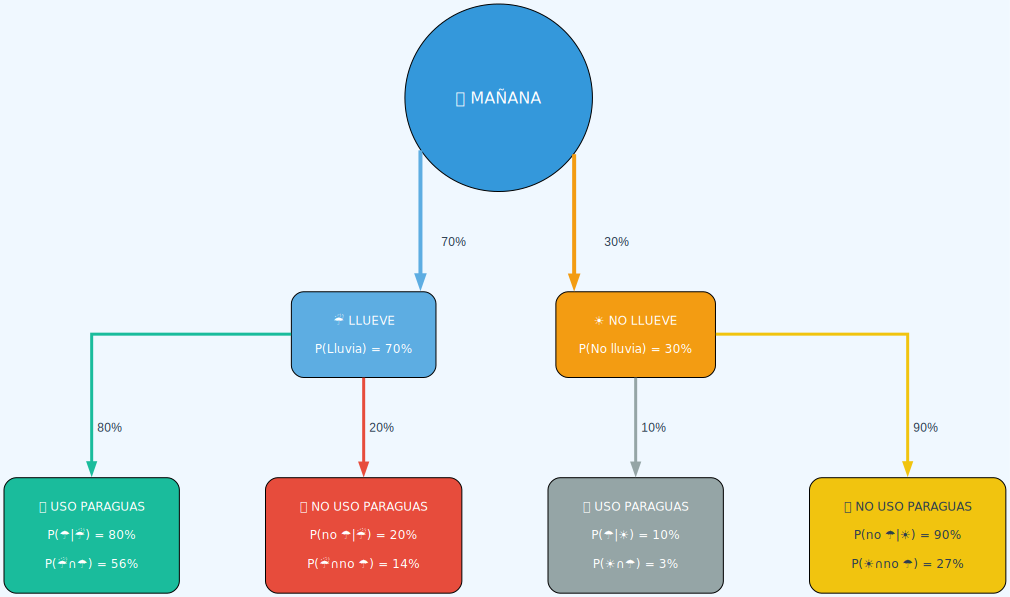

In [19]:
from graphviz import Digraph

# -----------------------------
# EJEMPLO: Pronóstico del Tiempo ☔
# -----------------------------

# Probabilidades del clima
p_lluvia = 0.70
p_no_lluvia = 0.30

# Si LLUEVE
p_paraguas_si_llueve = 0.80
p_no_paraguas_si_llueve = 0.20

# Si NO LLUEVE
p_paraguas_si_no_llueve = 0.10
p_no_paraguas_si_no_llueve = 0.90

# -----------------------------
# Probabilidades conjuntas (hojas del árbol)
# -----------------------------
p_lluvia_y_paraguas = p_lluvia * p_paraguas_si_llueve
p_lluvia_y_no_paraguas = p_lluvia * p_no_paraguas_si_llueve
p_no_lluvia_y_paraguas = p_no_lluvia * p_paraguas_si_no_llueve
p_no_lluvia_y_no_paraguas = p_no_lluvia * p_no_paraguas_si_no_llueve

# -----------------------------
# Construcción del árbol
# -----------------------------
dot = Digraph("ArbolClima", format="png")

# Configuración general
dot.attr(rankdir="TB",
         fontname="Arial",
         fontsize="14",
         splines="ortho",
         bgcolor="#F0F8FF",
         nodesep="1.2",
         ranksep="1.2")

dot.attr('node',
         fontname="Arial Bold",
         fontsize="12",
         style="filled,rounded",
         margin="0.4,0.3")

dot.attr('edge',
         fontname="Arial",
         fontsize="12",
         fontcolor="#2C3E50",
         penwidth="3")

# Nodo inicial
dot.node("Inicio", "🌤️ MAÑANA",
         shape="circle",
         fillcolor="#3498DB",
         fontcolor="white",
         width="1.5",
         fontsize="16")

# Primer nivel: CLIMA
dot.node("Llueve", "☔ LLUEVE\n\nP(Lluvia) = 70%",
         shape="box",
         fillcolor="#5DADE2",
         fontcolor="white",
         style="filled,rounded",
         width="2")

dot.node("NoLlueve", "☀️ NO LLUEVE\n\nP(No lluvia) = 30%",
         shape="box",
         fillcolor="#F39C12",
         fontcolor="white",
         style="filled,rounded",
         width="2")

# Segundo nivel: DECISIÓN DE PARAGUAS (si llueve)
dot.node("LP", "🌂 USO PARAGUAS\n\nP(☂|☔) = 80%\n\nP(☔∩☂) = 56%",
         shape="box",
         fillcolor="#1ABC9C",
         fontcolor="white",
         style="filled,rounded")

dot.node("LNP", "🚶 NO USO PARAGUAS\n\nP(no ☂|☔) = 20%\n\nP(☔∩no ☂) = 14%",
         shape="box",
         fillcolor="#E74C3C",
         fontcolor="white",
         style="filled,rounded")

# Segundo nivel: DECISIÓN DE PARAGUAS (si NO llueve)
dot.node("NLP", "🌂 USO PARAGUAS\n\nP(☂|☀) = 10%\n\nP(☀∩☂) = 3%",
         shape="box",
         fillcolor="#95A5A6",
         fontcolor="white",
         style="filled,rounded")

dot.node("NLNP", "🚶 NO USO PARAGUAS\n\nP(no ☂|☀) = 90%\n\nP(☀∩no ☂) = 27%",
         shape="box",
         fillcolor="#F1C40F",
         fontcolor="#2C3E50",
         style="filled,rounded")

# Aristas
dot.edge("Inicio", "Llueve", label="  70%  ", color="#5DADE2", penwidth="4")
dot.edge("Inicio", "NoLlueve", label="  30%  ", color="#F39C12", penwidth="4")

dot.edge("Llueve", "LP", label="  80%  ", color="#1ABC9C", penwidth="3")
dot.edge("Llueve", "LNP", label="  20%  ", color="#E74C3C", penwidth="3")

dot.edge("NoLlueve", "NLP", label="  10%  ", color="#95A5A6", penwidth="3")
dot.edge("NoLlueve", "NLNP", label="  90%  ", color="#F1C40F", penwidth="3")

dot


**EJEMPLO: Pronóstico del Tiempo**

Contexto: Mañana hay 70% de probabilidad de lluvia.

Si llueve:

* 80% de probabilidad de que use paraguas
* 20% de que no lo use

Si NO llueve:

* 10% de probabilidad de que use paraguas (por precaución)
* 90% de que no lo use




### **Pregunta 2: ¿Cuál es la probabilidad de usar paraguas mañana?**

**Solución:**
```
P(Uso paraguas) = P(Llueve ∩ Paraguas) + P(No llueve ∩ Paraguas)
                = 0.56 + 0.03
                = 0.59 = 59%
```

**Interpretación:** Hay un 59% de probabilidad de que use paraguas mañana.

---

### **Pregunta 3: Si usé paraguas, ¿cuál es la probabilidad de que haya llovido realmente?**

**Solución (Teorema de Bayes):**
```
P(Lluvia | Uso paraguas) = P(Lluvia ∩ Paraguas) / P(Paraguas)
                          = 0.56 / 0.59
                          = 0.9492
                          ≈ 94.92%


---



**EJEMPLO: Control de Calidad (Aplicación industrial)**

Contexto: Una fábrica tiene 3 máquinas:
* Máquina A produce 50% de las piezas, con 2% defectuosas
* Máquina B produce 30% de las piezas, con 3% defectuosas
* Máquina C produce 20% de las piezas, con 5% defectuosas

Preguntas:
1. Dibuja el árbol con las 6 ramas posibles
2. ¿Qué porcentaje total de piezas son defectuosas?
3. Si encuentras una pieza defectuosa, ¿cuál es la probabilidad de que venga de la máquina C?

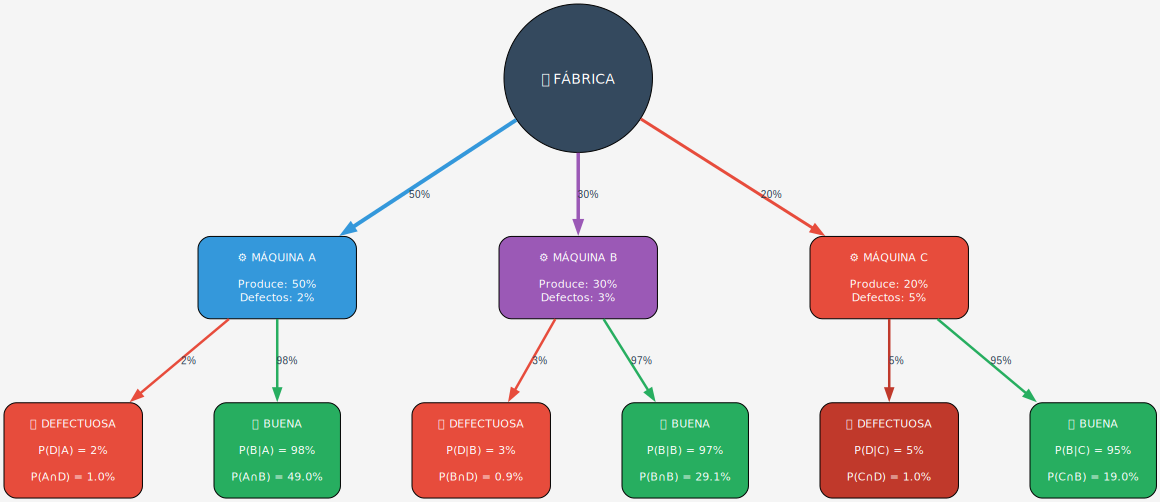

In [20]:
from graphviz import Digraph

# Probabilidades de producción de cada máquina
p_A = 0.50  # Máquina A produce 50%
p_B = 0.30  # Máquina B produce 30%
p_C = 0.20  # Máquina C produce 20%

# Tasas de defectos por máquina
p_defecto_A = 0.02  # 2% defectuosas en A
p_buena_A = 0.98

p_defecto_B = 0.03  # 3% defectuosas en B
p_buena_B = 0.97

p_defecto_C = 0.05  # 5% defectuosas en C
p_buena_C = 0.95

# Probabilidades conjuntas
p_A_defecto = p_A * p_defecto_A
p_A_buena = p_A * p_buena_A
p_B_defecto = p_B * p_defecto_B
p_B_buena = p_B * p_buena_B
p_C_defecto = p_C * p_defecto_C
p_C_buena = p_C * p_buena_C

# Construcción del árbol
dot = Digraph("ControlCalidad", format="png")

dot.attr(rankdir="TB",
         fontname="Arial",
         fontsize="12",
         bgcolor="#F5F5F5",
         nodesep="1.0",
         ranksep="1.0")

dot.attr('node',
         fontname="Arial Bold",
         fontsize="11",
         style="filled,rounded",
         margin="0.3,0.2")

dot.attr('edge',
         fontname="Arial",
         fontsize="10",
         fontcolor="#2C3E50",
         penwidth="2.5")

# Nodo inicial
dot.node("Inicio", "🏭 FÁBRICA",
         shape="circle",
         fillcolor="#34495E",
         fontcolor="white",
         width="1.2",
         fontsize="14")

# Máquinas
dot.node("A", "⚙️ MÁQUINA A\n\nProduce: 50%\nDefectos: 2%",
         shape="box",
         fillcolor="#3498DB",
         fontcolor="white",
         width="2.2")

dot.node("B", "⚙️ MÁQUINA B\n\nProduce: 30%\nDefectos: 3%",
         shape="box",
         fillcolor="#9B59B6",
         fontcolor="white",
         width="2.2")

dot.node("C", "⚙️ MÁQUINA C\n\nProduce: 20%\nDefectos: 5%",
         shape="box",
         fillcolor="#E74C3C",
         fontcolor="white",
         width="2.2")

# Resultados Máquina A
dot.node("A_D", "❌ DEFECTUOSA\n\nP(D|A) = 2%\n\nP(A∩D) = 1.0%",
         shape="box",
         fillcolor="#E74C3C",
         fontcolor="white")

dot.node("A_B", "✅ BUENA\n\nP(B|A) = 98%\n\nP(A∩B) = 49.0%",
         shape="box",
         fillcolor="#27AE60",
         fontcolor="white")

# Resultados Máquina B
dot.node("B_D", "❌ DEFECTUOSA\n\nP(D|B) = 3%\n\nP(B∩D) = 0.9%",
         shape="box",
         fillcolor="#E74C3C",
         fontcolor="white")

dot.node("B_B", "✅ BUENA\n\nP(B|B) = 97%\n\nP(B∩B) = 29.1%",
         shape="box",
         fillcolor="#27AE60",
         fontcolor="white")

# Resultados Máquina C
dot.node("C_D", "❌ DEFECTUOSA\n\nP(D|C) = 5%\n\nP(C∩D) = 1.0%",
         shape="box",
         fillcolor="#C0392B",
         fontcolor="white")

dot.node("C_B", "✅ BUENA\n\nP(B|C) = 95%\n\nP(C∩B) = 19.0%",
         shape="box",
         fillcolor="#27AE60",
         fontcolor="white")

# Aristas
dot.edge("Inicio", "A", label="50%", color="#3498DB", penwidth="4")
dot.edge("Inicio", "B", label="30%", color="#9B59B6", penwidth="3.5")
dot.edge("Inicio", "C", label="20%", color="#E74C3C", penwidth="3")

dot.edge("A", "A_D", label="2%", color="#E74C3C", penwidth="2.5")
dot.edge("A", "A_B", label="98%", color="#27AE60", penwidth="2.5")

dot.edge("B", "B_D", label="3%", color="#E74C3C", penwidth="2.5")
dot.edge("B", "B_B", label="97%", color="#27AE60", penwidth="2.5")

dot.edge("C", "C_D", label="5%", color="#C0392B", penwidth="2.5")
dot.edge("C", "C_B", label="95%", color="#27AE60", penwidth="2.5")

dot

**EJEMPLO: Control de Calidad (Aplicación industrial)**

Contexto: Una fábrica tiene 3 máquinas:
* Máquina A produce 50% de las piezas, con 2% defectuosas
* Máquina B produce 30% de las piezas, con 3% defectuosas
* Máquina C produce 20% de las piezas, con 5% defectuosas

Preguntas:

2. ¿Qué porcentaje total de piezas son defectuosas?

3. Si encuentras una pieza defectuosa, ¿cuál es la probabilidad de que venga de la máquina C?

In [21]:
# Tasas de defectos por máquina
p_defecto_A = 0.02  # 2% defectuosas en A
p_buena_A = 0.98

p_defecto_B = 0.03  # 3% defectuosas en B
p_buena_B = 0.97

p_defecto_C = 0.05  # 5% defectuosas en C
p_buena_C = 0.95

In [22]:
# Probabilidades conjuntas
p_A_defecto = p_A * p_defecto_A
p_A_buena = p_A * p_buena_A
p_B_defecto = p_B * p_defecto_B
p_B_buena = p_B * p_buena_B
p_C_defecto = p_C * p_defecto_C
p_C_buena = p_C * p_buena_C

¿Qué porcentaje total de piezas son defectuosas?

In [23]:
p_A_defecto + p_B_defecto + p_C_defecto

0.029

Si encuentras una pieza defectuosa, ¿cuál es la probabilidad de que venga de la máquina C?

In [24]:
# p_C_defecto
# total defectuosas: p_A_defecto + p_B_defecto + p_C_defecto

p_C_defecto/ (p_A_defecto + p_B_defecto + p_C_defecto)

0.3448275862068966



---



**EJEMPLO: Test de COVID-19**

Contexto: En una población, el 2% tiene COVID. Se aplica un test rápido con:
* Sensibilidad: 85% (detecta correctamente al 85% de infectados)
* Especificidad: 95% (da negativo correcto al 95% de sanos)

Preguntas para los alumnos:

1. Construye el árbol de probabilidades completo
2. Calcula P(COVID ∩ Test+)
3. Si alguien da positivo, ¿cuál es la probabilidad real de tener COVID? [P(COVID|Test+)]
4. ¿Por qué es tan bajo ese porcentaje?